## _Spoticore Stage 2 PyTorchified_

We are going to refactor the stage 2 code to (kinda) match PyTorch's public API for building neural networks similar to spoticore.

At the end, we will explore diagnostic visualizations to optimize parameter initialization. Here, we will revisit some previously introduced techniques and introduce new ones.


### Imports

In [119]:
from typing import Final
import torch
import torch.nn.functional as F
import torch.nn.init as Init
from math import sqrt
from collections.abc import Iterator
from typing import Protocol
from reader import read_all_unique_words


%matplotlib inline
import matplotlib.pyplot as plt

### Constants

In [120]:
SEED: Final[int] = 534150593
N_EMBD: Final[int] = 10
N_HIDDEN: Final[int] = 100

BLOCK_SIZE: Final[int] = 3

### Random seed generator

In [121]:
g = torch.Generator().manual_seed(SEED)

### Neural network architecture

In [122]:
class Layer(Protocol):
    def __call__(self, x: torch.Tensor) -> torch.Tensor: ...
    def parameters(self) -> Iterator[torch.Tensor]: ...

In [123]:
class Linear:
    def __init__(self, fan_in: int, fan_out: int, bias: bool = True) -> None:
        # Kaiming Init with a gain of 1 for linear layer.
        self.weight = torch.randn((fan_in, fan_out), generator=g) / sqrt(fan_in)
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self) -> Iterator[torch.Tensor]:
        yield self.weight
        if self.bias is not None:
            yield self.bias

In [124]:
class BatchNorm1d:
    def __init__(
        self, num_features: int, eps: float = 1e-5, momentum: float = 0.1
    ) -> None:
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # bn gain
        self.gamma = torch.ones(num_features)
        # bn bias
        self.beta = torch.zeros(num_features)
        # bn running mean and variance
        self.running_mean = torch.zeros(num_features)
        self.running_var = torch.ones(num_features)

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        # forward pass: calculate activations
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var

        # normalize to unit variance
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)

        self.out = self.gamma * xhat + self.beta

        # update running mean and var
        if self.training:
            with torch.no_grad():
                self.running_mean = (
                    1 - self.momentum
                ) * self.running_mean + self.momentum * xmean
                self.running_var = (
                    1 - self.momentum
                ) * self.running_var + self.momentum * xvar

        return self.out

    def parameters(self) -> Iterator[torch.Tensor]:
        yield self.gamma
        yield self.beta

In [125]:
class Tanh:
    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        self.out = torch.tanh(x)
        return self.out

    def parameters(self) -> Iterator[torch.Tensor]:
        return iter(())

### Build character-index mappings from training data

In [126]:
type StoiMap = dict[str, int]
type ItosMap = dict[int, str]


def build_vocab_mappings() -> tuple[list[str], StoiMap, ItosMap]:
    words = read_all_unique_words()

    chars = sorted(set("".join(words)))

    # create mappings with special token "." at index 0.
    stoi = {char: i + 1 for i, char in enumerate(chars)}
    stoi["."] = 0

    itos = {i: char for char, i in stoi.items()}

    return words, stoi, itos

### Construct model inputs from training data

In [127]:
words, stoi, itos = build_vocab_mappings()
vocab_size = len(stoi)

In [128]:
def construct_model_inputs(
    words: list[str], stoi: StoiMap, block_size: int = 3
) -> tuple[torch.Tensor, torch.Tensor]:
    block_size = 3

    X, Y = [], []

    for word in words:
        prev_chars_is = [0] * block_size
        for char in word + ".":
            nxt_char_i = stoi[char]
            X.append(prev_chars_is)
            Y.append(nxt_char_i)
            prev_chars_is = prev_chars_is[1:] + [nxt_char_i]

    return torch.tensor(X), torch.tensor(Y)

### Construct embedding lookup matrix

In [129]:
# Char -> N_EMBD row vector
C = torch.randn((vocab_size, N_EMBD), generator=g)

### Create deep MLP

In [130]:
layers = [
    Linear(N_EMBD * BLOCK_SIZE, N_HIDDEN),
    BatchNorm1d(N_HIDDEN),
    Tanh(),
    Linear(N_HIDDEN, N_HIDDEN),
    BatchNorm1d(N_HIDDEN),
    Tanh(),
    Linear(N_HIDDEN, N_HIDDEN),
    BatchNorm1d(N_HIDDEN),
    Tanh(),
    Linear(N_HIDDEN, N_HIDDEN),
    BatchNorm1d(N_HIDDEN),
    Tanh(),
    Linear(N_HIDDEN, N_HIDDEN),
    BatchNorm1d(N_HIDDEN),
    Tanh(),
    Linear(N_HIDDEN, vocab_size),
    BatchNorm1d(vocab_size),
]

### Kaiming Init for tanh

In [131]:
gain = Init.calculate_gain("tanh")

# make last layer less confident
with torch.no_grad():
    # if last layer is batchnorm
    layers[-1].gamma *= 0.1
    # if last layer is linear
    # layers[-1].weight *= 0.1

    # apply gain for all tanh pre-activations
    # output layer does not perform tanh
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= gain

### Initialize model parameters for training

In [132]:
params = [C] + [p for layer in layers for p in layer.parameters()]
print("Total parameters: ", sum(p.nelement() for p in params))

# ensure all parameters take part in backprogation
for p in params:
    p.requires_grad = True

Total parameters:  48681


### Train the model

In [133]:
X, Y = construct_model_inputs(words, stoi)

In [134]:
iterations = 20_000
batch_size = 32
lr = 0.2

# Loss in iterations passsed through log10()
losses = []


# Track update ratio to parameters per training iteration.
update_ratios: list[float] = []

for i in range(iterations):
    # Construct mini batch of inputs
    chosen_idxs = torch.randint(0, X.shape[0], (batch_size,), generator=g)

    # Extract the batches.
    X_batch, Y_batch = X[chosen_idxs], Y[chosen_idxs]

    # Forward pass.
    emb = C[X_batch]

    x = emb.view((batch_size, N_EMBD * BLOCK_SIZE))

    for layer in layers:
        x = layer(x)

    loss = F.cross_entropy(x, Y_batch)

    # Backward pass.
    for layer in layers:
        # Non-leaf tensors do not store gradients by default.
        # Needed for visualization that tracks update ratio to weights.
        layer.out.retain_grad()

    for p in params:
        p.grad = None

    loss.backward()

    # Update params

    for p in params:
        if p.grad is not None:
            p.data += -lr * p.grad

    # track stats
    if i % 1000 == 0:
        print(f"{i:7d} / {iterations}: {loss.item():.4f}")

    losses.append(loss.log10().item())

    # Dont build a computational graph with these tensor operations.
    with torch.no_grad():
        update_ratios.append(
            [
                (lr * param.grad.std() / param.data.std()).log10().item()
                if param.grad is not None and param.data.std() > 0
                else float("nan")
                for param in params
            ]
        )

      0 / 20000: 3.6171
   1000 / 20000: 2.4553
   2000 / 20000: 2.8961
   3000 / 20000: 2.6089
   4000 / 20000: 2.6753
   5000 / 20000: 2.5961
   6000 / 20000: 2.7770
   7000 / 20000: 2.6724
   8000 / 20000: 2.7247
   9000 / 20000: 2.4619
  10000 / 20000: 2.7055
  11000 / 20000: 2.3200
  12000 / 20000: 2.4329
  13000 / 20000: 2.0845
  14000 / 20000: 2.5172
  15000 / 20000: 2.5192
  16000 / 20000: 2.2476
  17000 / 20000: 2.7319
  18000 / 20000: 2.5046
  19000 / 20000: 2.4944


 ### Logic behind `update_ratios` 
 
 `update_ratios` is a list that stores the ratio of update magnitude to parameter magnitude for each parameter at each training step. This helps us track how much each parameter is changing relative to its current value during training.
 
 The behaviour of a layer's update ratio can help us analyze whether the layer is learning too fast (possible update overshots leading to oscillating losses) or too slow (training takes too long). Hence, this data can be used to pick an optimal learning rate.
 
 We use std to measure the ratio to get a stable and easy to understand measure of update magnitude relative to parameter scale. 
 
 We dont use mean to calculate the ratio because mean can be near zero and make computed ratios undefined or misleading.
 
 What the ratio means:
 
  - too small (e.g., < 0.001): Updates are tiny relative to parameters so learning may be slow.
 
  - too large (e.g., > 0.1): Updates are large relative to parameters so learning may be unstable or diverge.
 
 Ideal stable update range is often around 0.001–0.01 (-3 to -2 in log10 scale). In other words, we want the update magnitude to be around 0.001 - 0.1 of the parameter magnitude for the training to be stable.
 
 Note:
 
 > This "ideal range" is an empirical rule based on observations from past research.
 >
 > It is most useful as a diagnostic tool at the start of training to check if initialization is reasonable.
 >
 > The optimal range can vary by problem, optimizer, and architecture.



## Visualizations

### Visualize tanh activation density in forward pass

Change the gain for the tanh layers and observe the activation distribution.

layer 2 (Tanh): mean -0.01, std 0.67, saturated: 6.59%
layer 5 (Tanh): mean -0.01, std 0.69, saturated: 9.34%
layer 8 (Tanh): mean -0.00, std 0.70, saturated: 8.94%
layer 11 (Tanh): mean +0.00, std 0.71, saturated: 8.44%
layer 14 (Tanh): mean +0.01, std 0.72, saturated: 8.19%


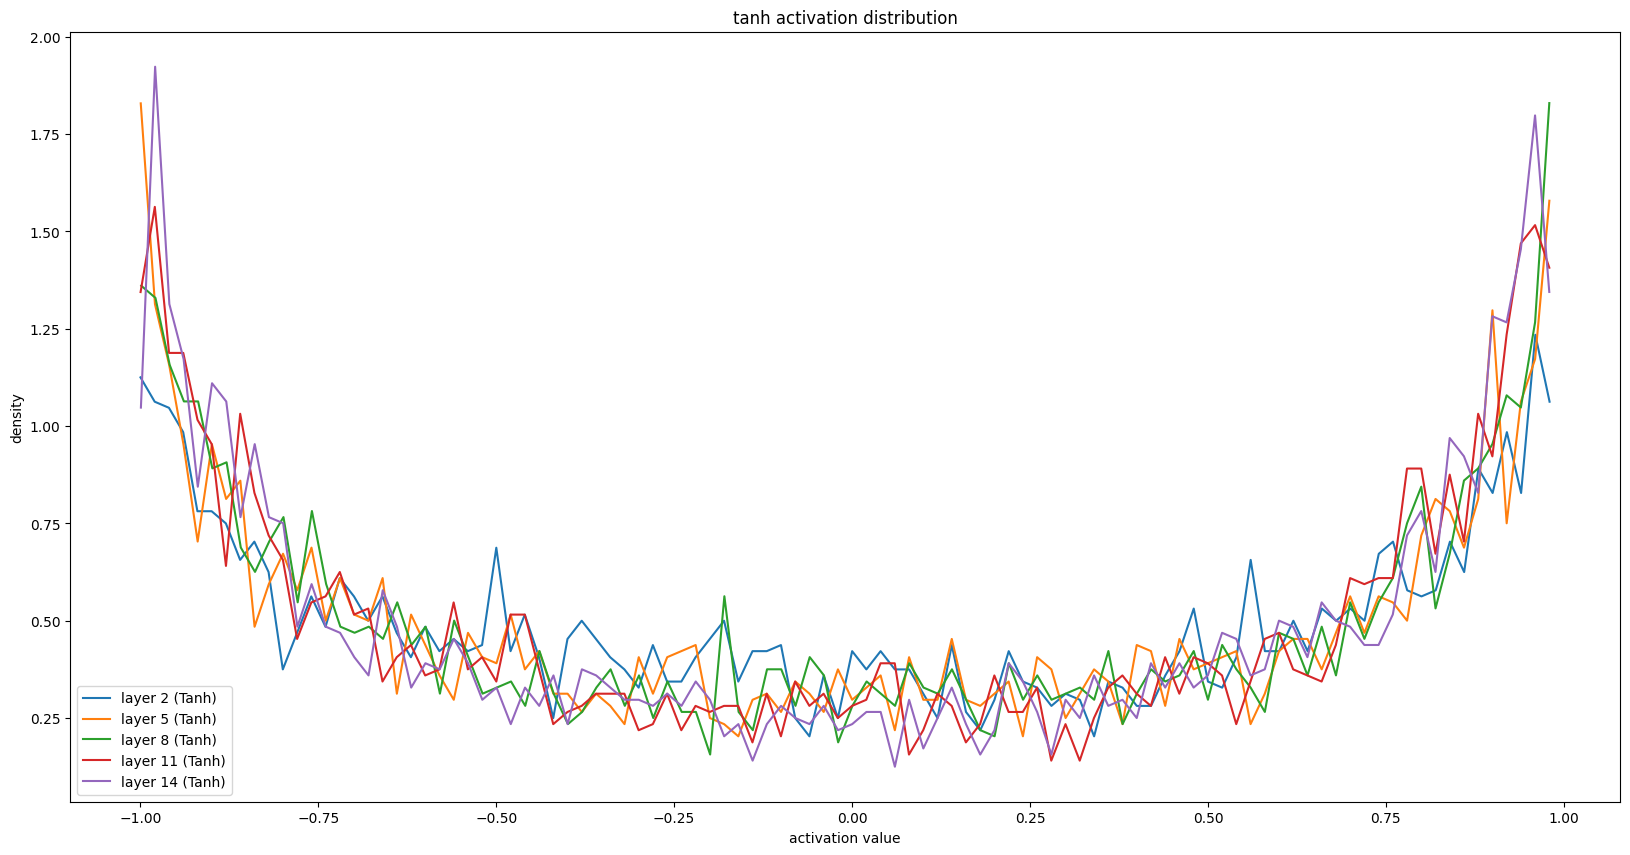

In [135]:
# Histogram visualization.

plt.figure(figsize=(20, 10))

legends: list[str] = []

for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        # Retrieve tanh layer's activations.
        acts = layer.out.detach()

        print(
            "layer %d (%s): mean %+.2f, std %.2f, saturated: %.2f%%"
            % (
                i,
                layer.__class__.__name__,
                acts.mean(),
                acts.std(),
                (acts.abs() > 0.97).float().mean() * 100,
            )
        )
        # Construct layer's x, y values.
        hx, hy = torch.histogram(acts, density=True)

        # Plot layer's activation distribution.
        plt.plot(hy[:-1].detach(), hx.detach())

        legends.append(f"layer {i} ({layer.__class__.__name__})")


plt.legend(legends)
plt.title("tanh activation distribution")
plt.xlabel("activation value")
plt.ylabel("density");

### Visualize tanh gradient density in forward pass

Change the gain for the tanh layers and observe the activation gradient distribution.

layer 2 (Tanh): mean +0.000000, std 2.481657e-03
layer 5 (Tanh): mean -0.000000, std 2.384150e-03
layer 8 (Tanh): mean +0.000000, std 2.370358e-03
layer 11 (Tanh): mean -0.000000, std 2.333467e-03
layer 14 (Tanh): mean -0.000000, std 2.334817e-03


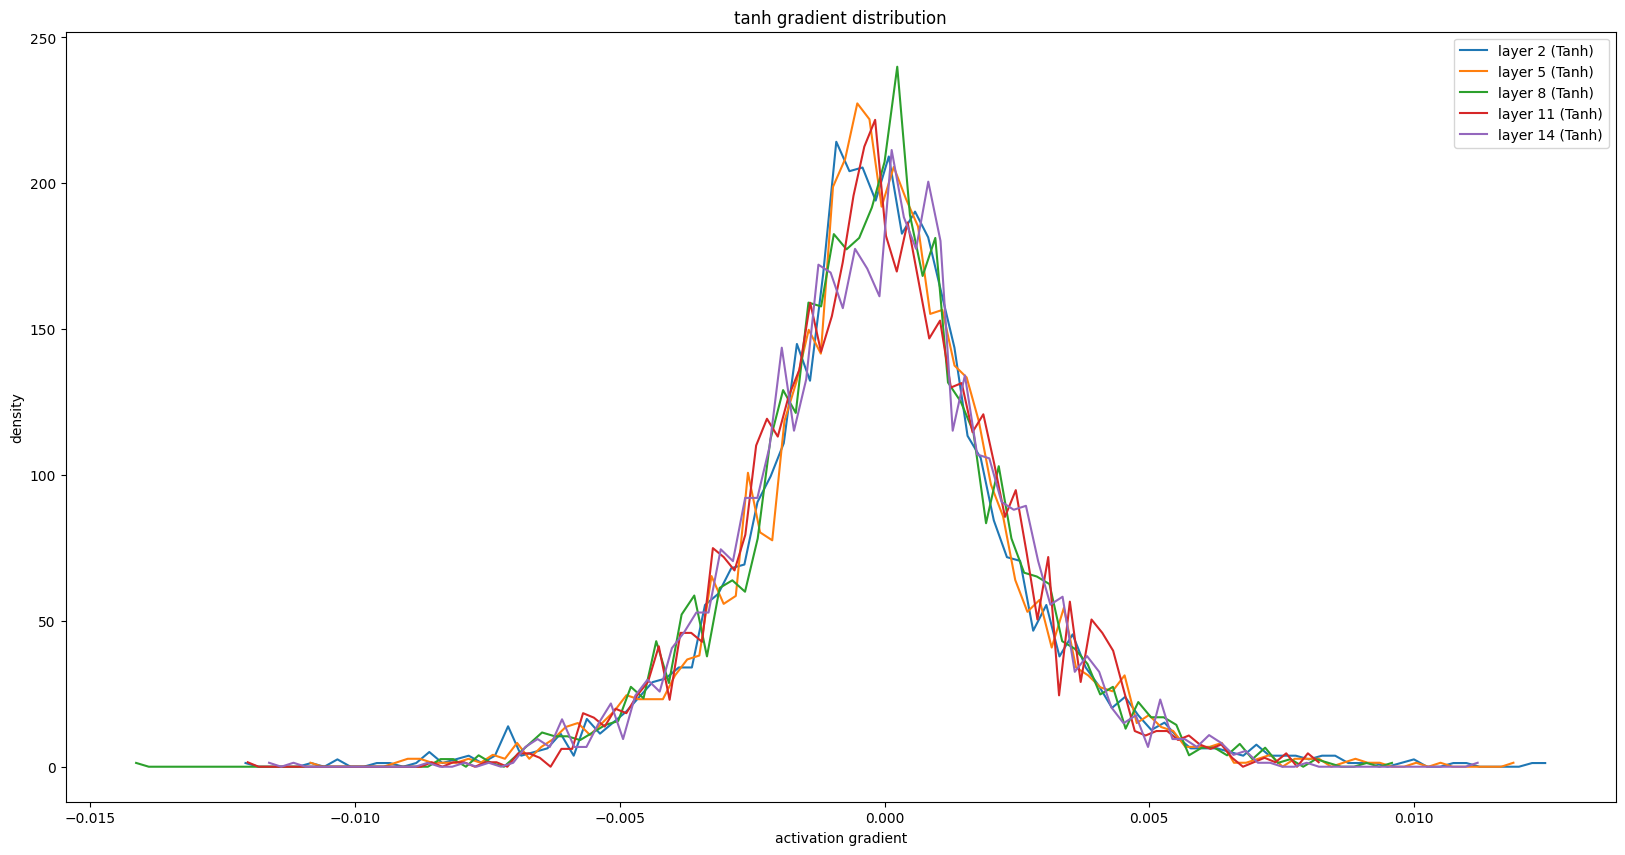

In [136]:
plt.figure(figsize=(20, 10))

legends: list[str] = []

for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        # Retrieve tanh layer's gradients.
        grads = layer.out.grad

        assert grads is not None

        print(
            "layer %d (%s): mean %+f, std %e"
            % (
                i,
                layer.__class__.__name__,
                grads.mean(),
                grads.std(),
            )
        )
        # Construct layer's x, y values.
        hx, hy = torch.histogram(grads, density=True)

        # Plot layer's activation gradient distribution.
        plt.plot(hy[:-1].detach(), hx.detach())

        legends.append(f"layer {i} ({layer.__class__.__name__})")


plt.legend(legends)
plt.title("tanh gradient distribution")
plt.xlabel("activation gradient")
plt.ylabel("density");

### Gradient distribution of weight matrices

Observe the __grad:data__ ratio for each layer, especially the final layer.

The histogram highlights whether the final layer requires a scaling down of their weights at the __start of training__. In a deep network with 100s of hidden layers, the gradients can shrink by a drastic amount at each layer going backwards due to extreme weight values in the final layer from random sampling:

```py
# Deep network with 10 layers
# If gradients shrink by 0.5x at each layer going backwards:

Layer 10: gradient = 0.01
Layer 9:  gradient = 0.005
Layer 8:  gradient = 0.0025
...
Layer 1:  gradient = 0.0000195  # Nearly zero!
```

We see that this causes early layers to stay stuck at their random initialization even after gradient updates (because the gradients are tiny). Therefore, the early layers do not __learn__. The later layers learn but the early layers are basically _dead_.

Finally, as discussed before, weight saturation from the activation function can lead to the gradient of the weights to be exactly 0. This literally stops training because the weights do not get updated. When backpropagating, gradients flow through the chain rule and if any of the final layers are enough saturated, it can kill all layers before it as no gradients are backpropagated.

This diagnosis helps to check if weight initialization is appropriate with respect to gradient distribution when starting a new architecture. 

It is good practice to check this after one backward pass at the start of training. If gradients are bad from the start, no amount of training will fix it.

weight   (37, 10) | mean +0.000000  | std 7.693544e-03 | grad:data ratio 7.529511e-03
weight  (30, 100) | mean +0.000029  | std 5.583768e-03 | grad:data ratio 1.589159e-02
weight (100, 100) | mean -0.000022  | std 3.728446e-03 | grad:data ratio 1.815944e-02
weight (100, 100) | mean +0.000007  | std 3.629489e-03 | grad:data ratio 1.802125e-02
weight (100, 100) | mean -0.000008  | std 3.496523e-03 | grad:data ratio 1.751856e-02
weight (100, 100) | mean +0.000015  | std 3.441686e-03 | grad:data ratio 1.749789e-02
weight  (100, 37) | mean +0.000011  | std 5.565390e-03 | grad:data ratio 2.246968e-02


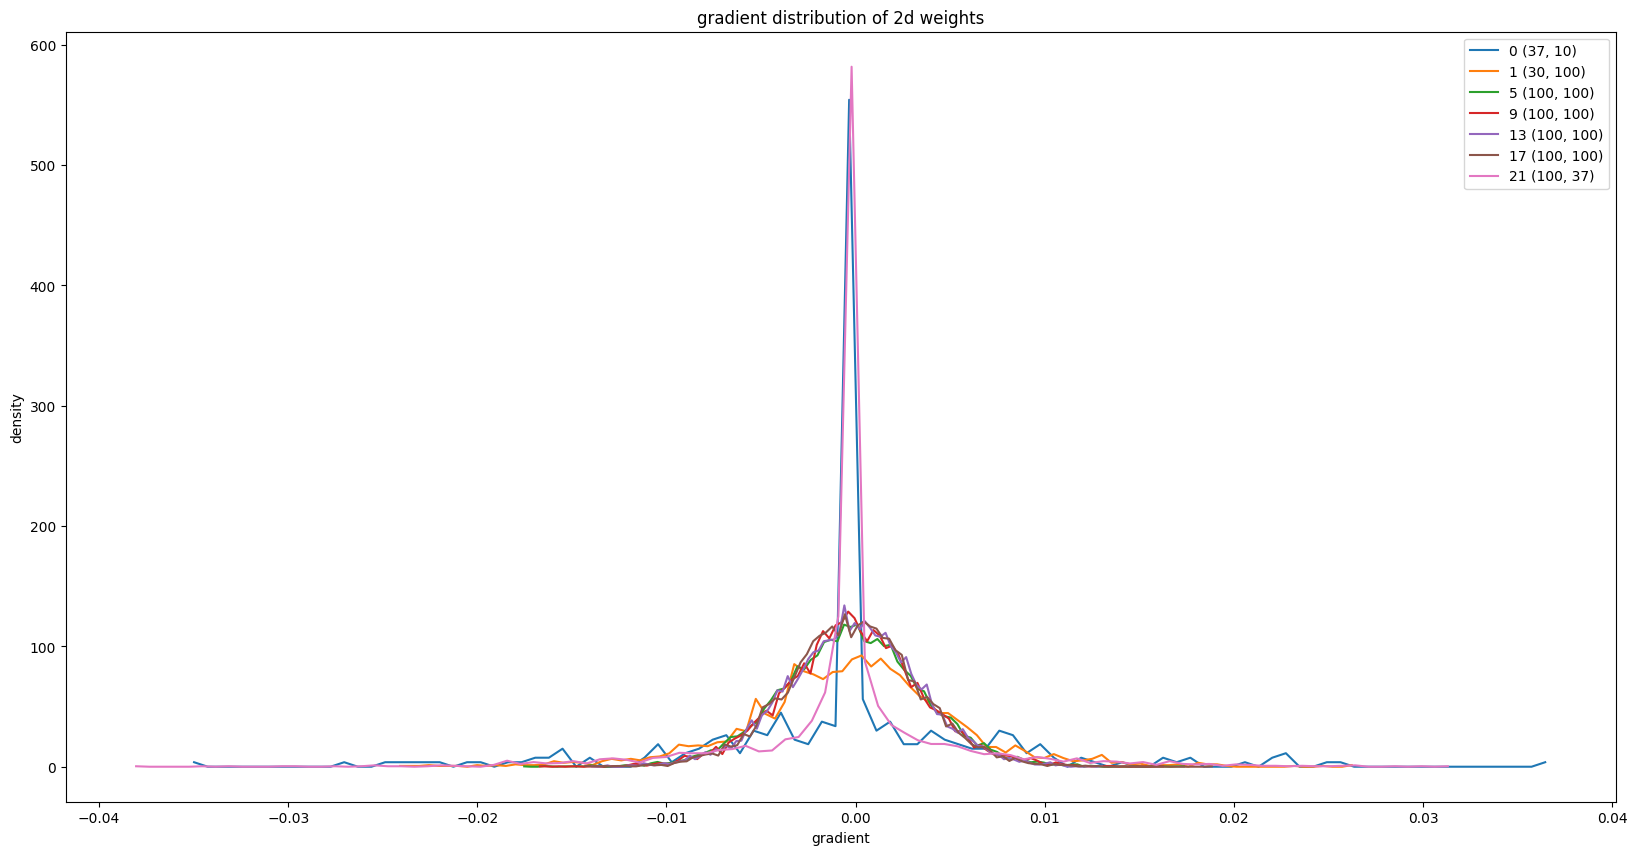

In [137]:
# Visualize the histogram.

plt.figure(figsize=(20, 10))
legends = []

for i, p in enumerate(params):
    if p.ndim == 2 and p.grad is not None:
        print(
            "weight %10s | mean %+f  | std %e | grad:data ratio %e"
            % (
                tuple(p.shape),
                p.grad.mean().item(),
                p.grad.std().item(),
                (p.grad.std() / p.data.std()).item(),
            )
        )
        # Derive histogram x, y values
        hx, hy = torch.histogram(p.grad, density=True)
        # Plot the graph
        plt.plot(hy[:-1].detach(), hx.detach())
        legends.append(f"{i} {tuple(p.shape)}")


plt.legend(legends)
plt.title("gradient distribution of 2d weights")
plt.xlabel("gradient")
plt.ylabel("density");

### Bad gradient initialization prevents efficient training

From the above histogram, we see that the last layer has a ratio of 1.58. This means that gradients are larger than the weights.

Thus, updates to the corresponding weight values will be too aggressive:

```py
weight = 0.1  # current weight value
gradient = 0.158  # gradient magnitude similar to weight
learning_rate = 0.2

# After one update:
new_weight = 0.1 - 0.2 * 0.158 = 0.0684  # Changed by 32%!
```

We see that the weights change by a big factor each step and this might lead to the next losses to oscillate widly or explode to infinity.

We might get NaN values which breaks training logic and even if we are lucky to avoid these worst case scenarios, the training will just bounce around the loss landscape instead of descenting smoothly.



We can reduce the learning rate drastically (e.g. 0.2 -> 0.001) to offset the big deductions in the weight values but this makes training 100x slower. 



### Visualize update/weight ratio over time

We plot `log10(ratio)` over training `iterations`.

This helps us monitor whether the gradient updates are proportionally too large relative to the actual weight values.
We must tracking this ratio to avoid the gradient instability issues discussed in the previous sections.

The ratios can vary by many magnitude (e.g. 0.0001 to 1.0) so
we use `log10()` to compress this wide ratio range into a more _compact readable_ range.

In this context:

```py
update = learning_rate × gradient.std()
data = parameter.std()

ratio = update/data
```

We want ensure an update ratio of > -3 because:

```py
log10(ratio) = -3
ratio = 10^(-3) = 0.001
```

As discussed beforehand, an ideal update ratio should be between 0.001 to 0.1. Since, we compress the ratios using `log10()`
the lower limit becomes -3 in our plot below.


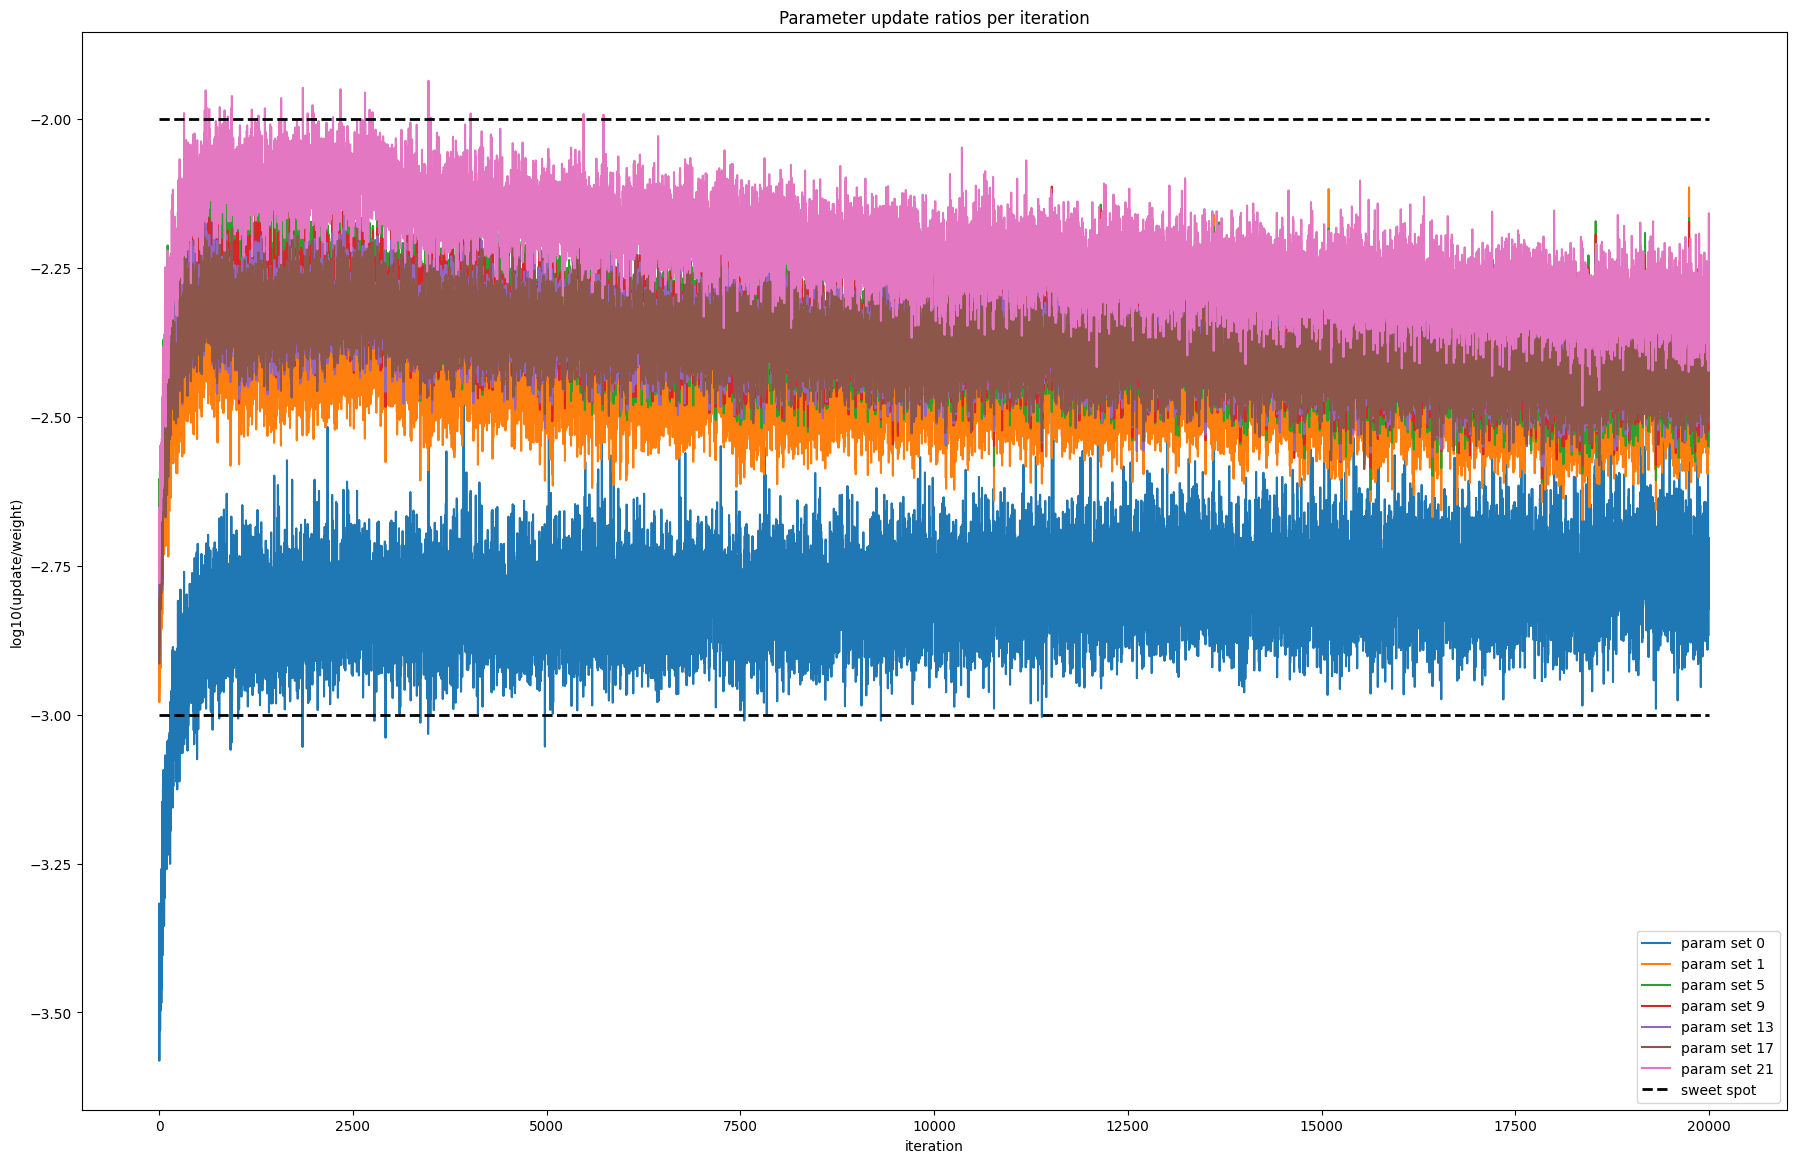

In [138]:
plt.figure(figsize=(22, 14))
legends = []

for i, p in enumerate(params):
    if p.ndim == 2:
        label = f"param set {i}"
        udr_values = [update_ratios[j][i] for j in range(len(update_ratios))]
        plt.plot(range(len(udr_values)), udr_values, label=label)
        legends.append(label)


# Define sweet spot range for stable training.
plt.plot([0, len(update_ratios)], [-3, -3], "k--", linewidth=2, label="min ratio")

plt.plot([0, len(update_ratios)], [-2, -2], "k--", linewidth=2, label="max ratio")
legends.append("sweet spot")

plt.legend(legends)
plt.xlabel("iteration")
plt.ylabel("log10(update/weight)")
plt.title("Parameter update ratios per iteration");

The above plot proves why BatchNorm works visually.

It keeps the training process stable and healthy across all layers throughout training (notice that almost all plots are within our ideal range).

Each layer's gradients neither vanish nor explode, which means that all nuerons are learning.
